## Assignment 4 - Distributed Kalman Filtering

- **Topic:** Distributed state estimation of a target
- **Assessment:** The assignment will be graded according to the grading rubric on Brightspace.


- **Deadline:** 27-03-2026, 17:00
- **Submitting: SUBMIT ONLY `assignment4_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your group number.


## Instructions
**Installation:** 
The virtual environment `venvPSF` has all the necessary packages pre-installed. Make sure to select the virtual environment when running the code. This can be done in the Jupyter notebook (in vscode) by clicking select kernel in the top right, then python environments, then myenv (python 3.11.9).

If you choose to install the virtual environment yourself, the full list of dependencies is in requirements.txt. This can be done using the steps as shown in howToInstallVirtualEnvironments.txt

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `helper.py` and `linAlg.py` and the data file `tracking_data.npz` as this might result in breaking the assignment.


## AI Related Policy
The use of AI is not allowed.


## Information
Please fill in your group number, names and student numbers in the cell below.

In [159]:
# YOUR ANSWER HERE
STUDENT_1_NAME = "Santiago Terreno Duarte"
STUDENT_1_STUDENT_NUMBER = "6144683"

STUDENT_2_NAME = "Pragun Srivastava"
STUDENT_2_STUDENT_NUMBER = "5542707"

### Description and Objectives

The primary objective of this assignment is to estimate the position of a maneuvering target in 2D using a network of anchors. The target is traveling along an unknown trajectory in two dimensions, within the sensing range of the anchors, which have fixed positions. The anchors can measure the radial distance between themselves and the target throughout its journey, with some noise.

We consider a scenario similar to (but not identical to) the figure shown below. In the figure, a network of fixed-position anchors (blue circles) measures the radial distances (red circles) between themselves and the target (represented as a purple triangle). To estimate the target's position the anchors need to communicate with one another, however, they are only allowed to interact with their immediate neighbors in the network as indicated by the gray dashed lines.

The main focus will be to collaboratively estimate the target's position using distributed state estimation, by implementing a distributed Kalman filter formulation.
\
![alt text](multiagent_tracking.png "Title") 

Each anchor is denoted by an integer $n \in \{1, 2, \dots, N\}$ where $N$ is the number of anchors in the network. 
At each time step $k$, anchors measure the squared distance $(d_{n,k})^2 \in \mathbb{R}^+$ between their (fixed) positions $\mathbf{z}_n \in \mathbb{R}^2$ and the target position $\mathbf{p}_k \in \mathbb{R}^2$ as
$$
    d_{n,k} \triangleq ||\mathbf{z}_n - \mathbf{p}_k ||_2.
$$
Unfortunately the measurement model is nonlinear and not suitable for a standard Kalman filter in this form.
We can however, tweak this formulation to obtain a linear form by squaring the distance and expanding the squared norm as
\begin{aligned}
    (d_{n,k})^2 &=  ||\mathbf{z}_n - \mathbf{p}_k ||_2^2 = (\mathbf{z}_n - \mathbf{p}_k)^T (\mathbf{z}_n - \mathbf{p}_k), \\
              &= (\mathbf{z}_n)^T \mathbf{z}_n - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    (d_{n,k})^2 - (\mathbf{z}_n)^T \mathbf{z}_n &= - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    y_{k,n} &= \tilde{\mathbf{C}}_n \tilde{\mathbf{p}}_k,
\end{aligned}
where $y_{k,n} \triangleq (d_{n,k})^2 - ||\mathbf{z}_n||_2^2, \quad  \tilde{\mathbf{C}}_n \triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T  &  1 \end{bmatrix}, \quad  \tilde{\mathbf{p}}_k \triangleq  \begin{bmatrix} \mathbf{p}_k^T & ||\mathbf{p}_k||_2^2 \end{bmatrix}^T$.
Notice that we added $||\mathbf{p}_k||_2^2$ as a state variable to make this measurement model linear.

To use this approach, let us define the state vector of the target as 
$$ 
\mathbf{x}_k \triangleq \begin{bmatrix} \mathbf{p}_k^T & \dot{\mathbf{p}}_k^T &  ||\mathbf{p}_k||_2^2 \end{bmatrix}^T,
$$
where $ \dot{\mathbf{p}}_k \in \mathbb{R}^2 $ represents the velocity vector.
We can now formulate a state space model to use it for state estimation. 
Denote the state space equations as
\begin{aligned}
    \mathbf{x}_{k+1} &= \mathbf{A} \mathbf{x}_k + \mathbf{w}, \quad \mathbf{w} \sim \mathcal{N}(0, \mathbf{Q}), \\
    y_{k,n} &= \mathbf{C}_n \mathbf{x}_k + v, \quad v \sim \mathcal{N}(0, R),
\end{aligned}
where we choose the dynamic model matrix $\mathbf{A}$ and $\mathbf{C}_n$ as
\begin{aligned}
    \mathbf{A} &\triangleq \text{blkdiag} \biggl( \begin{bmatrix} 1 & \Delta t_k \\ 0 & 1 \end{bmatrix} \otimes \mathbb{I}_2, 1 \biggr), \\
    \mathbf{C}_n &\triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T & 0 & 0 & 1 \end{bmatrix}, \\
\end{aligned}
and $ \Delta t_k $ is the time difference between time step $k+1$ and $k$.

### Provided data
First let us load the simulated data, the data consists of the following elements
- `dt` $\in \mathbb{R}^+$ (float): Time difference between consecutive time steps
- `T` $\in \mathbb{N}$ (int): Number of time steps where time steps $k$ span from $0$ to $T-1$
- `edge_list` (list of tuples): Stores the edges as `(i,j)` which denotes the connection between anchors `i` and `j`.
- `anchor_positions` $\in \mathbb{R}^{2 \times N}$ (numpy array): Horizontally stacked anchor position vectors $[\mathbf{z}_1, \ \mathbf{z}_2, \ \dots, \mathbf{z}_N]$ 
- `measurement_list` $\in \mathbb{R}^{N \times T}$ (numpy array): List of measurements $y_{k,n}$ where `measurement_list[n, k]` denotes the measurement of anchor `n` at time step `k`.
- `true_positions` $\in \mathbb{R}^{2 \times T}$ (numpy array): Horizontally stacked true positions of the target $[\mathbf{p}_0, \ \mathbf{p}_2, \ \dots, \mathbf{p}_{T-1}]$ 

After we load the data, let us see what the anchor network, the ground truth trajectory and measurements look like. Note that the measurements plotted as two dimensional points just for clarity. Actual measurements look more like circles since we only measure the radial distances.

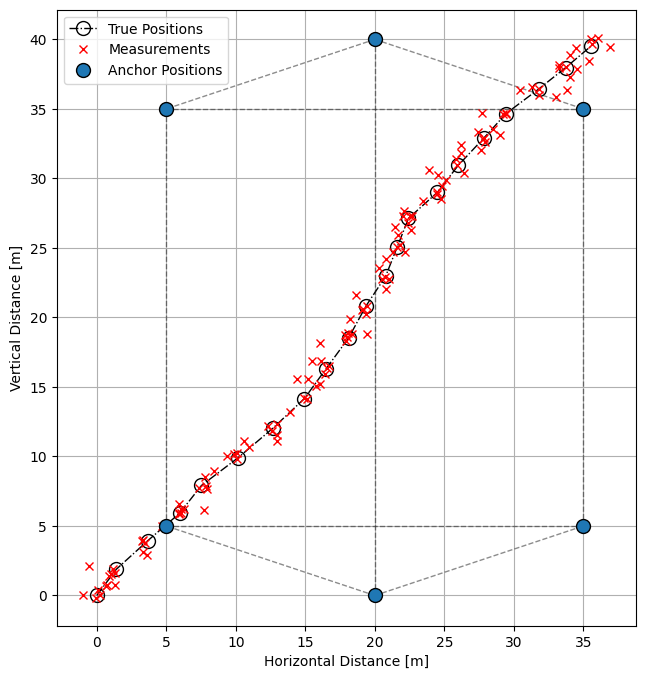

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from linAlg import block_diag
import helper as helper


plt.rcParams.update(
    {
        "lines.linewidth": 1.0,
        "lines.markersize": 10,
        "lines.markeredgewidth": 1.0
        
    }
)
measurement_list, true_states, anchor_positions, edge_list, dt, T, model_parameters = helper.initializeDKFAssignment()

helper.plotMeasurementsAndGroundTruth(true_states, anchor_positions, edge_list, model_parameters)


### Task 1: Construct Matrices
Construct dynamic model matrix $\mathbf{A}$ and measurement model matrices $\mathbf{C}_n$ as described above. 
You can use the parameters `initial_mean` vector,`initial_covariance` matrix, process covariance matrix `Q` and measurement noise variance `R` provided below for the rest of the assignment. 
You can use `block_diag` function to construct $\mathbf{A}$.


### Analysis:
Elaborate on the following:
- Why do we add the new variable $||\mathbf{p}_k||_2^2$ to the state vector? If we wanted to avoid doing this, how would you proceed? 
- Comment on the dynamic update model of the state variable $||\mathbf{p}_k||_2^2$. Does it properly represent the true dynamics? If not, what can be done to mitigate its drawbacks?

## Answer

- We add the state variable because otherwise the measurement model is non linear. To avoid doind it, we could linearize around each current estimate, obtaining a linear model for each step (similar to non-linear Kalman filter).
  
- The dynamic update for that state variable, due to the construction of matrix A, is $||\mathbf{p}_{k+1}||_2^2$ = $||\mathbf{p}_k||_2^2$ + noise. It imposes that the distance between the target and a reference position at the origin does not change much between one step and the next. Strictly speaking the model is not physically accurate, but the added noise regulates how strict the impoition that the target distance to the origin remains unchanged is. How strict this is depends on how we tune Q (that is, how much trust we give to the dynamic model). If Q is low relatively to R then the estimated position will move slowly, independent of measurements, and if Q is high and R low then the measurements will be trusted more and the dynamics will be trusted less.

In [161]:
#####  YOUR CODE HERE #####

A1 = np.kron(np.array([[1, dt], [0, 1]]), np.eye(2))
A = block_diag(A1, np.array([[1]]))

N = anchor_positions.shape[1]
C = np.zeros([N, 5])

for n in range(N):
    znT = anchor_positions[:, n]
    C[n, :] = np.concatenate((-2*znT, np.array([0, 0, 1])))

##### END HERE #####


# Initial Mean and covariance
initial_estimate = np.zeros((5,1))
initial_covariance = np.eye(initial_estimate.shape[0])*100.0

# Process noise covariance (Q) and Measurement noise covariance (R)
Q = np.diag([1.5, 0.15, 1.5, 0.15, 100.0])
R = 0.75

### Task 2: Centralized Kalman Filter Implementation
Implement a centralized version of the Kalman filter by using all measurements generated by the anchors to update the state estimate. After each time step, append your mean and covariance estimates to lists `centralized_means` and `centralized_covariances` respectively.

Note that for the centralized measurement update version you can use an augmented measurement model in the form
\begin{aligned}
    \begin{bmatrix} y_{1,k} \\  y_{2,k} \\ ... \\  y_{N,k} \end{bmatrix} &= \begin{bmatrix} \mathbf{C}_1 \\  \mathbf{C}_2 \\ ... \\  \mathbf{C}_N   \end{bmatrix}  \mathbf{x}_k + \mathbf{v}, \quad \mathbf{v} \sim \mathcal{N}(0, R \ \mathbb{I}_N).
\end{aligned}

### Analysis:
Elaborate on the following:
- Comment on the centralized Kalman filter mean estimates. Explain how $||\mathbf{p}_k||_2^2$ is estimated without even measuring the variable itself.

## Answer

The means are the estimates of $ \mathbf{x}_k \triangleq \begin{bmatrix} \mathbf{p}_k^T & \dot{\mathbf{p}}_k^T &  ||\mathbf{p}_k||_2^2 \end{bmatrix}^T$. We are actually indiectly measuring the variable, because as can be seen in the derivation shown above, what we measure (or, more precisely, what is stored in the measurements list with which we work) is the quantity $(d_{n,k})^2 - (\mathbf{z}_n)^T \mathbf{z}_n = - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k$. Therefore, as seen in the measurement and dynamic model, with the measurements and the dyamics we estimate the right hand side of that equation through the Kalman filter, and the model contains $||\mathbf{p}_k||_2^2$. Therefore, $\|\mathbf{p}_k\|_2^2$ is estimated indirectly as part of the overall state estimation process. In this sense, the variable is observable through the measurement model, even though it is not directly measured.

IMPORTANT: We use range(T+1), so including the initial_estimate means that at the end the number of estimates is one more than the number of measurements. We assume that, if we want to estimate T+1 positions and are provided with T+1 measurements, then it is because the initial position is not known exactly (otherwise, if it was known, we wouldn't even need the first measurement). In that case, the initial estimate is just for initialization, but should not be treated as the estimate for the first position. The data for this exercise is a little weird in the sense that the initial estimate is exactly the initial position, and in practice knowing exactly the initial position meas that we don't need the first estimate. In this exercise we use the initial measurement to compute the error metrics, so we discard the initial_estimate, because we assume that we are not supposed to know exactly the initial position, since otherwise, as mentioned, one less measurement would have been provided.

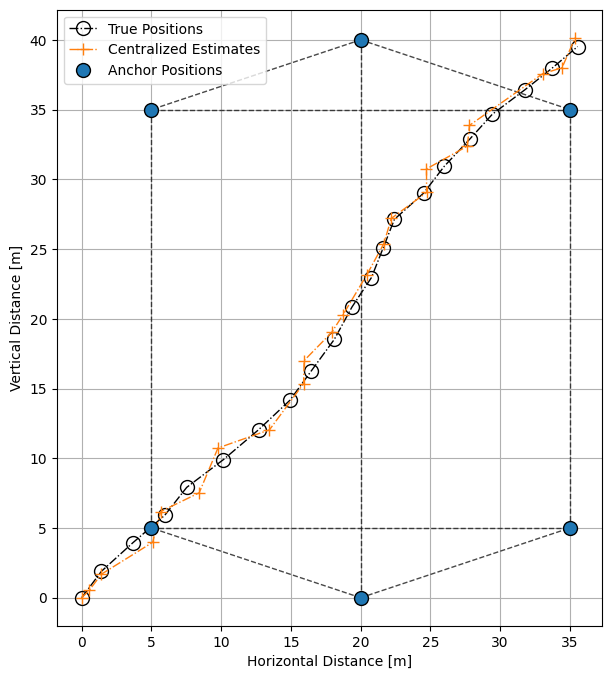

In [162]:
# Centralized estimates
centralized_means = [initial_estimate]
centralized_covariances = [initial_covariance]


#####  YOUR CODE HERE #####

x = initial_estimate.copy()
P = initial_covariance.copy()

RI = R*np.eye(N)
for k in range(T+1): # 

    # Time update
    x = A @ x
    P = A @ P @ A.T + Q
    
    # Measurement update
    S = RI + C @ P @ C.T
    K = P @ C.T @ np.linalg.inv(S)

    y = measurement_list[:, k:k+1]
    
    x = x + K @ (y - C @ x)
    P = P - K @ C @ P

    centralized_means.append(x.reshape([-1,1]))
    centralized_covariances.append(P)


##### END HERE #####


helper.plotCentralizedKFEstimate(true_states, anchor_positions, edge_list, centralized_means)

### Task 3: Distributed Kalman Filter Implementation
Implement a distributed Kalman filter using the formulation given below. After each time step, append your mean and covariance estimates for anchor `n` to lists `local_means[n]` and `local_covariances[n]` respectively.




Assume that anchor $n$ has access to measurements of itself and its neighbors $j \in \mathcal{N}_n \cup \{n\}$.
At time $k$, a local estimate can be computed using the following procedure:

\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k+1 | k}  \\
&P_{n, k+1 | k} = A P_{n, k+1 | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&x_{n,k} = \hat{x}_{n, k | k-1} \\
&P_{n,k} = P_{n, k | k-1} \\
&\text{For each} \ j \in \mathcal{N}_n \cup \{n\} \ \text{repeat:} \\
& \quad S_{j,k} = C_{j} P_{n,k} C_{j}^T + R_{j} \\
& \quad K_{j,k} = P_{n,k} C_{j}^T S_{j,k}^{-1} \\
& \quad x_{n,k} = x_{n,k} + K_{j,k} (y_{j,k} - C_{j} x_{n,k})\\
& \quad P_{n,k} = P_{n,k} - K_{j,k}  C_{j}  P_{n,k} \\
&\text{end} \\
&\hat{x}_{n, k | k} = x_{n,k} \\
&P_{n, k | k} = P_{n,k} \\
\end{aligned}

Alternatively a more compact from  can be expressed, similar to the information form KF, as
\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k | k}  \\
&P_{n, k+1 | k} = A P_{n, k | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&P_{n,k | k}^{-1} = P_{n,k | k-1}^{-1} + \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T  R_{j}^{-1}  C_{j}  \\
&\hat{x}_{n, k | k} = \hat{x}_{n,k | k-1} + P_{n,k|k} \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T R_{j}^{-1} (y_{j, k} - C_{j}\hat{x}_{n,k | k-1}  )\\
\end{aligned}

### Analysis:
Elaborate on the following:
- Analyze the behavior of the decentralized Kalman filter. At a glance, how does it differ from the centralized one?
- How would the estimates change if you change the number of edges. Comment on what would happen if all edges were removed.
- How many neighbors does an anchor need for a feasible solution? In other words, how many neighbors are required for each anchor to estimate a position? You may provide a geometric interpretation.

## Answer

- Instead of computing one global estimate using all the measurements, we just compute different estimates for each cluster of measurements. We have one cluster for each anchor, containing the measurments of the anchor itself and of the anchors that are connected with it. Therefore, each anchor only has a limited amount of information to estimate the position at each step, since it doesn't access all the measurements, generating an estimate that is in principle worse than an estimate using all the measurments. For that reason, in the plot there are 6 estimates shown, one for each anchor and its neighbours, and they are all worse estimates than the obtained using CFK. As covered in the lecture, under certain conditions we ca use consensus to generate a result that approximates that of centralized Kalman filter.

- As a general rule, the less number of anchors in each cluster, the worse that cluster will perform. However, less edges makes the problem less computationally expensive (although in this particular poblem the difference is insignificant).If we remove all the edges, it means that each cluster is composed by only one anchor, and therefore the performance would be worse than with edges. But more than that, the algorithm will not even work properly in this case, since the measurements are of the radial distance from each anchor, meaning that the target could lie anywhere on a cicunference centered at that anchor. Therefore, a unique position cannot be determined from a single measurement, and the estimates will be unreliable. In the other extreme, connecting every anchor to all the others would produce 6 identical estimators, all equal to CKF.

- Since each anchor measures the radial distance from itself to the target, at least three measurements (including its own) are required for each cluster to estimate the position. This is because three radial measurements are the minimum needed to uniquely determine a point in two dimensions. Geometrically, each measurement defines a circle, and the target position corresponds to the intersection of these circles. Three is the minimum number of circles that can intersect at one point (excluding the case of two cirles intersecting at a tangent point, irrelevant in practice). It is also required that the anchors are non-collinear, because if they are aligned, the measurements do not provide enough independent information and the position remains ambiguous (typically resulting in multiple possible intersection points).

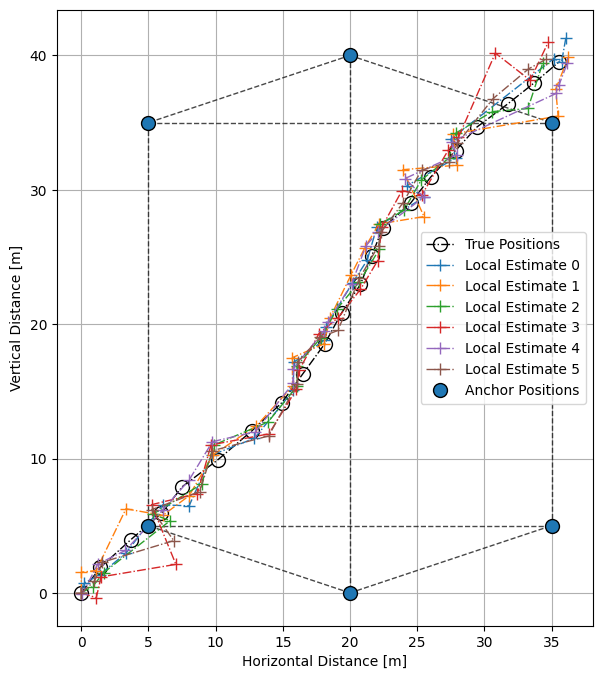

In [163]:
# Initialize per anchor variables
local_means = [[initial_estimate] for _ in range(anchor_positions.shape[1])]
local_covariances = [[initial_covariance] for _ in range(anchor_positions.shape[1])]

#### YOUR CODE HERE ####
use_stacked_update_method = True

N = anchor_positions.shape[1]

edges_matrix = np.zeros([N,N])
for edge in edge_list:
    edges_matrix[edge[0], edge[1]] = 1
    edges_matrix[edge[1], edge[0]] = 1
    
edges_matrix += np.eye(N)
 
for n in range(N):
    
    neighbor_idx = np.where(edges_matrix[n] == 1)[0]

    if use_stacked_update_method:
        RIn = R*np.eye(len(neighbor_idx))
        Cn = C[neighbor_idx,:]
        Yn = measurement_list[neighbor_idx,:]
    
    xn = initial_estimate.copy()
    Pn = initial_covariance.copy()
    
    for k in range(T+1):
    
        # Time update
        xn = A @ xn
        Pn = A @ Pn @ A.T + Q
        
        # Measurement update
        if use_stacked_update_method:
            Sn = RIn + Cn @ Pn @ Cn.T
            Kn = Pn @ Cn.T @ np.linalg.inv(Sn)
        
            yn = Yn[:, k:k+1]
            
            xn = xn + Kn @ (yn - Cn @ xn)
            Pn = Pn - Kn @ Cn @ Pn

        else:
            for j in neighbor_idx:
                Cj = C[j:j+1, :]
                yj = measurement_list[j, k]
    
                Sj = Cj @ Pn @ Cj.T + R
                Kj = Pn @ Cj.T @ np.linalg.inv(Sj)
    
                xn = xn + Kj @ (yj - Cj @ xn)
                Pn = Pn - Kj @ Cj @ Pn
        
        local_means[n].append(xn.reshape([-1,1]))
        local_covariances[n].append(Pn)


#### END HERE ####

helper.plotDecentralizedKFEstimate(true_states, anchor_positions, edge_list, local_means)



### Task 4: Comparison
Compute the squared errors of the centralized and local position mean estimates and plot them against time instances. Make sure that the axes are labeled with appropriate units. Also include a legend with descriptive names for each estimate.

### Analysis:
- Compare and discuss the filter performances. 
- What are the main advantages and disadvantages of centralized and decentralized Kalman filters?

## Answer

- The CKF is clearly th eine that performs the best. In some time instances the difference is not that big, but in others huge peaks can be seen in the error of the estimate of some anchors. By observing the 2 biggets peaks, a couple of interesting things can be seen. First of all, anchors 0 and 4 are present in the second peak, but not in the first, and the opposite is true for anchors 2 and 5. After inspecting which anchor is which in the anchor_positions variable, we see that this makes total sense, since anchors 0 and 4 are the ones in the bottom left, and 2 and 5 the ones in the top right. Since the target moves from bottom-left to top-right, the first group is closer at the beginning and far away towards the end, and the opposite for the second group. A perfectly reasonable assumption is that the performance tends to degrade as the target is further from the anchor, so the observed behaviour makes sense. Moreover, anchors 1 and 3 ae present in both peaks, and they are precisely the ones that are consistently further away from the target (bottom-right and top-left, respectively). Computational expensiveness is also an important part of performance, but in this case the differences are absolutely negligible. When they are not, then it makes more sense to use Local KF.

- As mentioned, when it can be implemented, the CKF will in general always perform better than any local KF (obviously, this would not be the case if some measurments were actively conspiring against the estimate and those were not present in the local KF, but that is another problem entirely, and could also be treated in CFK by manipulating the covariance). The estimates of local KF can theoretically approach the results of CKF (but never improve in theory, excluding model errors and outliers), although it is an asymptotic approach and under certain coditions. So, in terms of accuracy of estimates, CKF is better. But, the main reasons why in practice it is of interest to use local KF is because, first, CKF can be very computaitonally expensive if there are many measurements, especially because of the need to invert the matrix S. Local KF is much less expensive. And second, there are cases in which not all measurements are available to all agents, as in distributed systems, and therefore local KF is the best that can be done for those agents. 

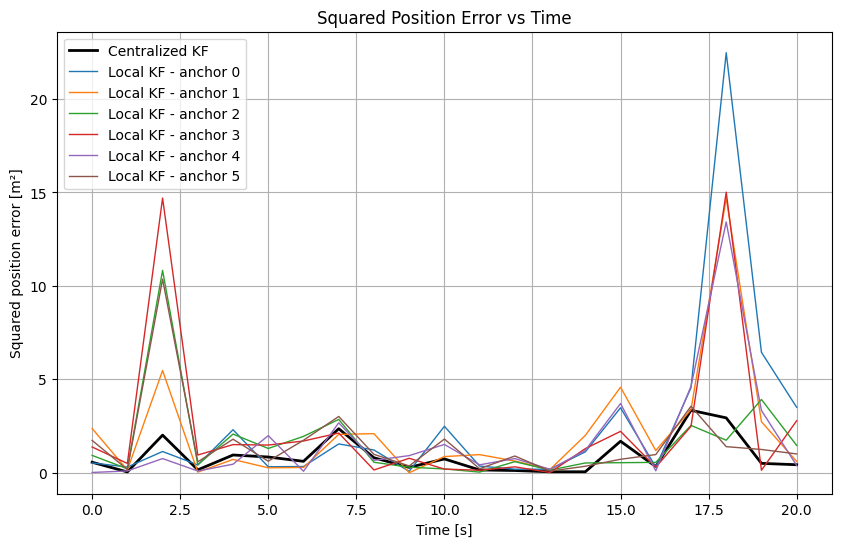

In [164]:
#### YOUR CODE HERE ####

true_positions = true_states[:2, :]

estimated_positions_centralized = np.array(centralized_means[1:])[:,:,0][:,:2].T
se_centralized = np.sum((true_positions - estimated_positions_centralized)**2, axis=0)

se_local = []
for local_means_anchor in local_means:
    estimated_positions_local = np.array(local_means_anchor[1:])[:,:,0][:,:2].T
    se_local.append(np.sum((true_positions - estimated_positions_local)**2, axis=0))

time = np.arange(T+1) * dt

plt.figure(figsize=(10, 6))

plt.plot(time, se_centralized, color='black', label='Centralized KF', linewidth=2)

for n, se in enumerate(se_local):
    plt.plot(time, se, label=f'Local KF - anchor {n}')

plt.xlabel('Time [s]')
plt.ylabel('Squared position error [m²]')
plt.title('Squared Position Error vs Time')
plt.legend()
plt.grid(True)
plt.show()

#### END HERE ####

#### Feedback:
Please use this markdown to share any comments, suggestions, or errors you encountered in the assignment. Your feedback will help us to improve it for future years.